L'idée est de tester si la simple représentation sous forme de graphe avec une fonction de coût adaptée fournit les mêmes résultats pour le transport, que ceux obtenus en utilisant les *embeddings*. Cela permet de valider ou pas la pertinence d'une telle approche.

## Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import deque, defaultdict
from tqdm import tqdm
from data_utils import *
from OT_utils import *
from information_content import *

## Chargement des données

In [2]:
hp_ids = []
parents_list = []

with open("../data/HPOs.csv", "r") as f:
    next(f)
    for line in f:
        hp_id = line.split(';')[0]
        
        # Extraire uniquement la liste contenant des IDs HP:XXXXXXX
        match = re.search(r"\[([^\]]*'HP:\d{7}'[^\]]*)\]", line)
        if match:
            parents = re.findall(r"HP:\d{7}", match.group(0))
        else:
            parents = []
        
        hp_ids.append(hp_id)
        parents_list.append(parents)

df_hpo = pd.DataFrame({'hp_id': hp_ids, 'parents': parents_list})

G_hpo_work = nx.DiGraph()
for hp_id in hp_ids:
    G_hpo_work.add_node(hp_id)
for hp_id, parents in zip(hp_ids, parents_list):
    for parent_id in parents:
        if parent_id in G_hpo_work:
            G_hpo_work.add_edge(hp_id, parent_id)

objects_w = list(G_hpo_work.nodes())
node2id_w = {n: i for i, n in enumerate(objects_w)}

In [3]:
def read_hpoa(path):
    with open(path, 'r') as f:
        skip = sum(1 for line in f if line.startswith('#'))
    return pd.read_csv(path, sep='\t', skiprows=skip, low_memory=False)

df_hpoa = read_hpoa('../data/phenotype_omim_orpha.hpoa')
df_hpoa['disease_name'] =df_hpoa['disease_name'].str.lower().str.strip().str.replace(r'[\s\-]+', ' ', regex=True)
df_hpoa.tail()

correspondence_exacte = build_disease_correspondence(df_hpoa)
print(f"Correspondances trouvées : {len(correspondence_exacte)}")

# Construction de deux dataframes à partir de df_hpoa
df_pivot = df_hpoa[['database_id', 'hpo_id']].drop_duplicates()
df_pivot['values']=1.
df_pivot = pd.pivot_table(data=df_pivot, values='values', index='database_id', columns='hpo_id', aggfunc='max', fill_value=0)
df_pivot.columns.name = None
df_pivot = df_pivot.reset_index()

df_orpha = df_pivot[df_pivot['database_id'].str.startswith('ORPHA:')]
df_orpha = df_orpha[df_orpha['database_id'].isin(correspondence_exacte['orpha_id'])]

df_omim = df_pivot[df_pivot['database_id'].str.startswith('OMIM:')]
df_omim = df_omim[df_omim['database_id'].isin(correspondence_exacte['omim_id'])]

Correspondances trouvées : 550


In [4]:
# Avec df_omim et df_orpha issus directement de df_hpoa
omim_to_idx = {v: i for i, v in enumerate(df_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(df_orpha['database_id'].values)}

ground_truth = []
for _, row in correspondence_exacte.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

df_gt_set = set(ground_truth)

## Fonction de coût

### Pondération par l'*Information Content*

In [5]:
weights, _, _ = compute_information_content(df_omim, G_hpo_work)
weights = {t:1/w for t, w in weights.items()}

In [6]:
def cost_matrix_hamm(df_omim, df_orpha, weights, block_size=256):
    n = df_omim.shape[0]
    m = df_orpha.shape[0]
    C = np.zeros((n, m))

    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    all_hpo = list(hpo_cols)
    weights_vector = np.array([weights.get(hp, 0.0) for hp in all_hpo])

    omim_matrix = df_omim.reindex(columns=all_hpo, fill_value=0)[all_hpo].values.astype(float)
    orpha_matrix = df_orpha.reindex(columns=all_hpo,  fill_value=0)[all_hpo].values.astype(float)
    
    for i_start in tqdm(range(0, n, block_size)):
        i_end = min(i_start + block_size, n)
        block = omim_matrix[i_start:i_end]
        diff = np.abs(block[:, None, :] - orpha_matrix[None, :, :])
        C[i_start:i_end] = (diff * weights_vector).sum(axis=2)
    return C

In [7]:
C = cost_matrix_hamm(df_omim, df_orpha, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

100%|██████████| 3/3 [00:47<00:00, 15.93s/it]

======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.702 (386/550)
Top-3 accuracy : 0.705 (388/550)
Top-5 accuracy : 0.705 (388/550)
 Rang moyen: 76.23
======== Avec régularisation ========
17913.730145857426
Paires évaluées : 550
Top-1 accuracy : 0.693 (381/550)
Top-3 accuracy : 0.825 (454/550)
Top-5 accuracy : 0.853 (469/550)
 Rang moyen: 16.36


### Pondération par la profondeur des noeuds dans le graphe

In [8]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(df_omim, df_orpha, depths)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C1)

100%|██████████| 3/3 [00:39<00:00, 13.16s/it]

======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.824 (453/550)
Top-5 accuracy : 0.824 (453/550)
 Rang moyen: 49.14
======== Avec régularisation ========
3.8610095206611574
Paires évaluées : 550
Top-1 accuracy : 0.842 (463/550)
Top-3 accuracy : 0.900 (495/550)
Top-5 accuracy : 0.911 (501/550)
 Rang moyen: 5.58


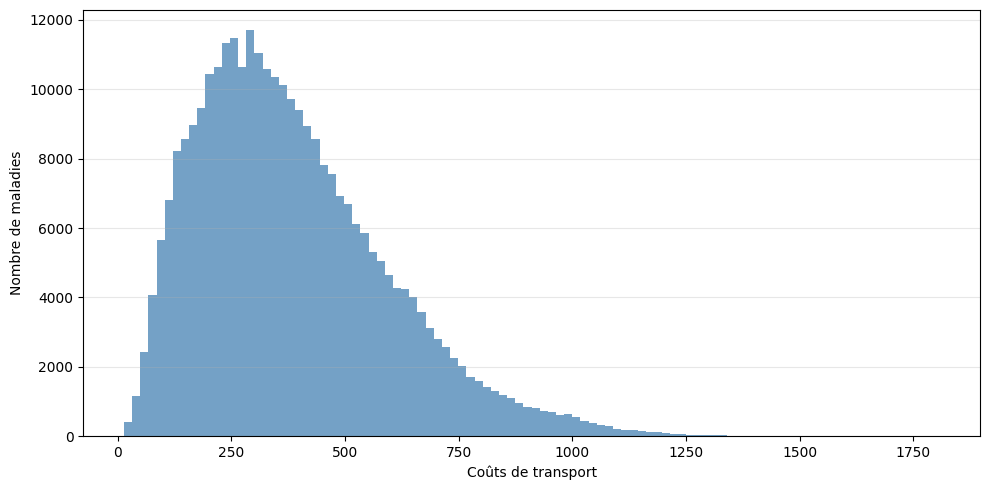

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(C1.ravel(), bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Coûts de transport")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

118/495


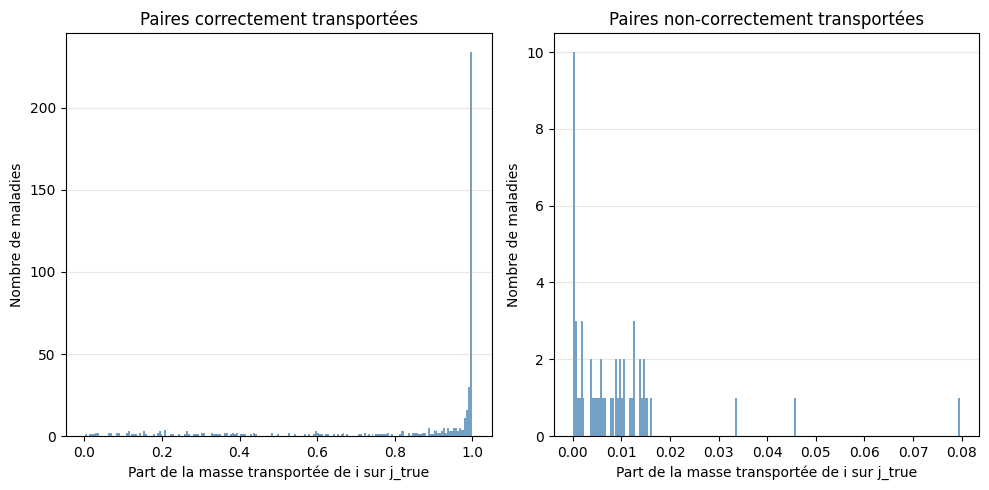

In [9]:
pairs_zero = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]
correct_pairs = [k for k, v in pairs_reg.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
print(f"{len([v for v in correct_transported_share if v < 0.8])}/{len(correct_transported_share)}")
uncorrect_transported_share = [v for k, v in transported_share.items() if k in pairs_zero]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
dict_ranks_w = {}
for i, k in enumerate(pairs_reg.keys()):
    dict_ranks_w[k]=ranks_reg[i]

pairs_zero_dict = {}
hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}
for (i,j) in  pairs_zero:
    j_pred = np.argmax(ot_plan_reg[i])
    omim_row = df_omim.iloc[i][hpo_cols]
    orpha_row = df_orpha.iloc[j][hpo_cols]
    orpha_row_pred = df_orpha.iloc[j_pred][hpo_cols]
    
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    orpha_pred_hpos = orpha_row_pred[orpha_row_pred==1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    pairs_zero_dict[(i, j)] = {
        "rank": dict_ranks_w[(i,j)],
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
        "cost_true": C1[i, j],
        "cost_pred": C1[i, j_pred],
        "predicted_disease" : pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j_pred]]['disease_name'])[0],
        "count_pred" : len(orpha_pred_hpos),
        "terms pred" : orpha_pred_hpos
    }

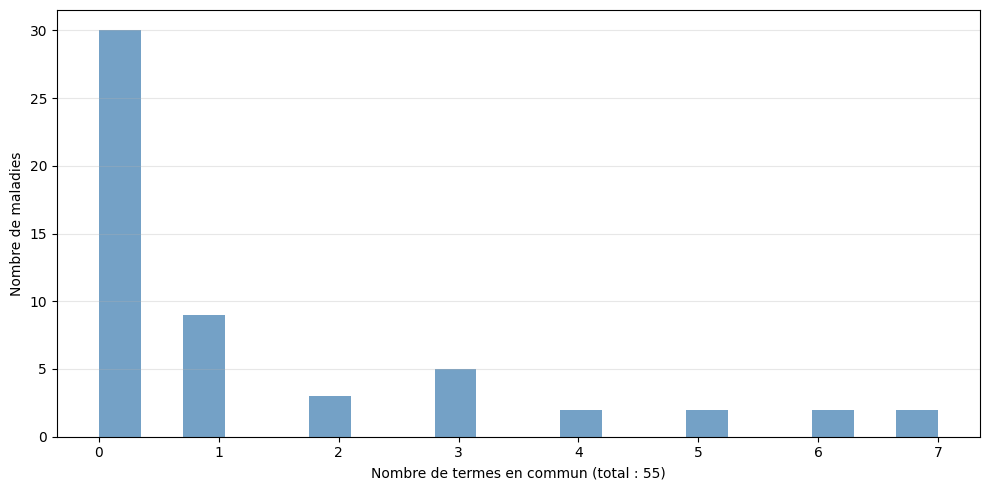

In [11]:
# Termes HP en commun parmi les maladies non associées
communs_w = np.array([len(v['commun'])  for v in pairs_zero_dict.values()])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(communs_w, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes en commun (total : {len(communs_w)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

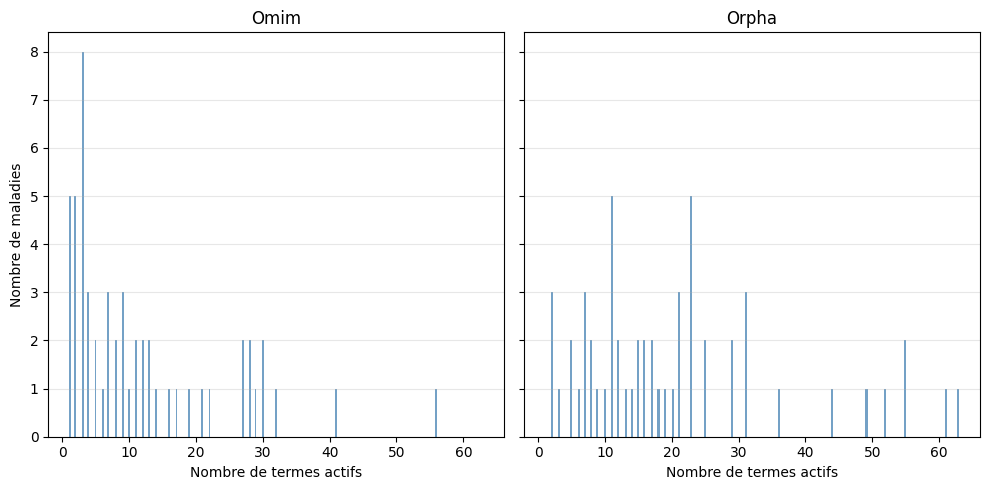

In [12]:
# Nombre de termes omim dans les maladies que l'on ne retrouve pas
omim_counts = np.array([v['omim']['count']  for v in pairs_zero_dict.values()])
orpha_counts = np.array([v['orpha']['count'] for v in pairs_zero_dict.values()])


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(omim_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(orpha_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
df = pd.read_csv("../data/utils/paires_zero_wass.csv")

paires_zero_dict_wass = {}
for _, row in df.iterrows():
    key = (row["i"], row["j"])
    paires_zero_dict_wass[key] = {
        "rank": row["rank"],
        "omim": {
            "name": row["omim_name"],
            "count": row["omim_count"],
            "terms": row["omim_terms"].split("|")
        },
        "orpha": {
            "name": row["orpha_name"],
            "count": row["orpha_count"],
            "terms": row["orpha_terms"].split("|")
        },
        "commun": set(row["commun"].split("|")) if pd.notna(row["commun"]) else set(),
        "cost_true": row["cost_true"],
        "cost_pred": row["cost_pred"],
        "terms_pred": row["terms_pred"]
    }

In [30]:
print("Maladies mal associées dans les deux cas :", len(set(paires_zero_dict_wass.keys())& set(pairs_zero_dict.keys())))
print(len(paires_zero_dict_wass.keys()))
print(len(pairs_zero_dict.keys()))

inter = set(paires_zero_dict_wass.keys()) & set(pairs_zero_dict.keys())
comp = {k:v for k, v in pairs_zero_dict.items() if k not in inter}
intersect = {k:v for k,v in pairs_zero_dict.items() if k in inter}
print(np.median(sorted([intersect[k]["rank"] for k in intersect.keys()])))
print(np.median(sorted([comp[k]["rank"] for k in comp.keys()])))

Maladies mal associées dans les deux cas : 25
46
55
32.0
15.0


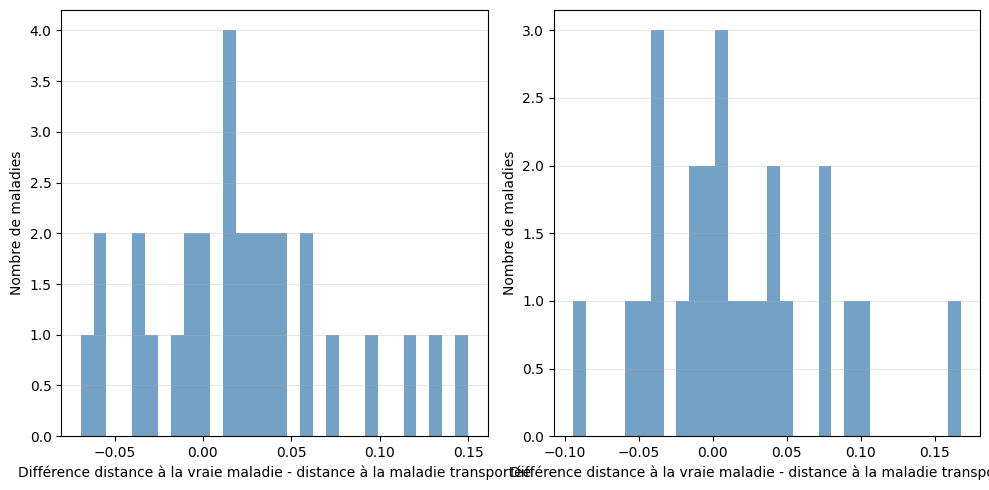

In [37]:
cost_gap_comp = [(comp[k]["cost_true"]-comp[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in comp.keys()]
cost_gap_inter = [(intersect[k]["cost_true"]-intersect[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in intersect.keys()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]

sns.histplot(cost_gap_comp, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(cost_gap_inter, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()